# **Assignment-8**

## **1. Dataset loading and preprocessing**

### Extract the Fashion MNIST dataset and use the following code to load it:

    train_dataset = torchvision.datasets.FashionMNIST(root=file path of the folder, train=True, transform=transform, download=False)

### Normalize the pixel intensities to have mean and standard deviation 0.5

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [3]:
train_dataset = torchvision.datasets.FashionMNIST(root='/home/142301026/Downloads/Deep_Learning/Lab8/lab_8_data', train=True, transform=transform, download=False)

In [4]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)

## **2. Define GAN generator**

### a. Design a generator network that takes a noise vector of dimension 100 as input and outputs a grayscale image of size 28x28. Use at least one dense layer, a final Conv2DTranspose layer, LeakyReLU activation function and a tanh output function.

In [5]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(100, 128*7*7)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 1, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, 128, 7, 7)
        return self.net(x)

generator = Generator()

### b. Show an image using untrained generator

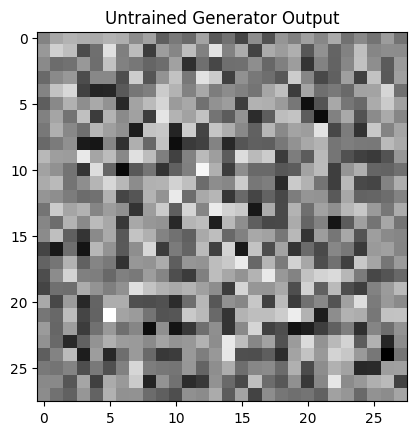

In [6]:
noise = torch.randn(1, 100)
fake_img = generator(noise).detach().cpu().squeeze()

plt.imshow(fake_img, cmap='gray')
plt.title("Untrained Generator Output")
plt.show()

## **3. Define GAN discriminator**

### a. Design a discriminator network that takes a grayscale image (28x28) as input and outputs a single scalar probability of the input being real. Use a simple architecture with Conv2D layers and dense layers with LeakyReLU activation.

In [7]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(128*7*7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

discriminator = Discriminator()

### b. Classify the image generated in 2(c) using the untrained discriminator.

In [8]:
pred = discriminator(generator(noise)).item()
print(f"Discriminator output (untrained): {pred:.3f}")

Discriminator output (untrained): 0.501


## **4. GAN training**

### a. Implement the training loop where you train the discriminator and generator in turn.
    • Sample a mini batch of real images as well as another of noise vectors.
    • Use the generator to generate fake images from the noise vectors.
    • Classify the real and fake images using the discriminator and then update the discriminator weights.
    • Next train the generator using the loss on the discriminator’s prediction for the fake images.

### **Note that the discriminator is trained on two sets of data and the generator on only one. Also recall that while we train the discriminator to distinguish between real and fake images, the generator should be trained so that the discriminator identifies the generator’s output as real.**

### Use the Adam optimizer and binary cross-entropy loss for both models. You might have to experiment with a few different learning rates to see good performance.

In [9]:
criterion = nn.BCELoss()

optimizer_G = optim.Adam(generator.parameters(), lr=0.0002)
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002)

### b. Train your GAN for enough epochs to see generated images start to take shape.

### c. Display 10 generated images after each epoch and observe how they vary. Example code to display a minibatch of images of size (N x H x W x C) in rows and columns:

### convert images to the required format by permuting channels if required
    fake_images = torch.permute(fake_images, (0, 2, 3, 1))
    plt.imshow(fake_images[i], cmap=’gray’)

Epoch 1: Loss_D=0.8735257983207703, Loss_G=2.095142126083374


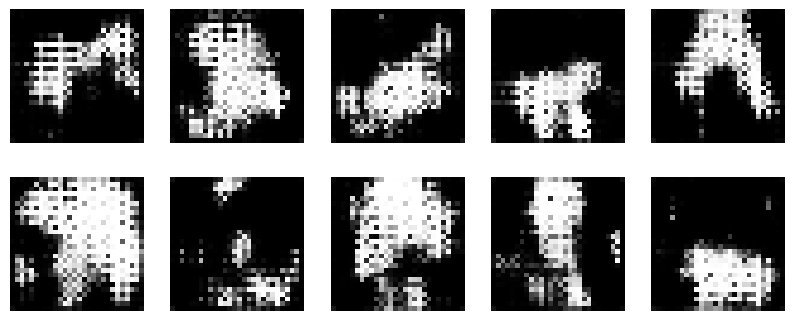

Epoch 2: Loss_D=0.8579946756362915, Loss_G=1.7814427614212036


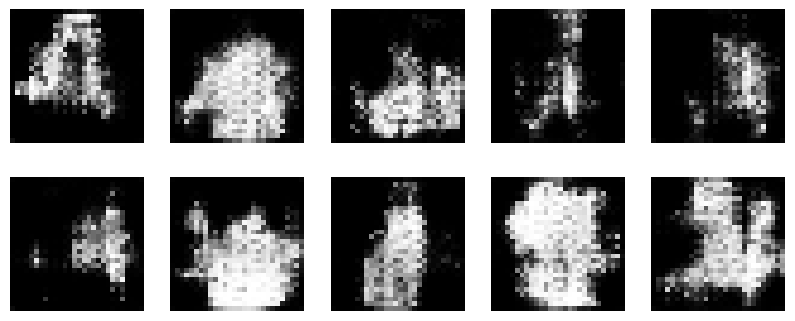

Epoch 3: Loss_D=1.3231210708618164, Loss_G=1.0099478960037231


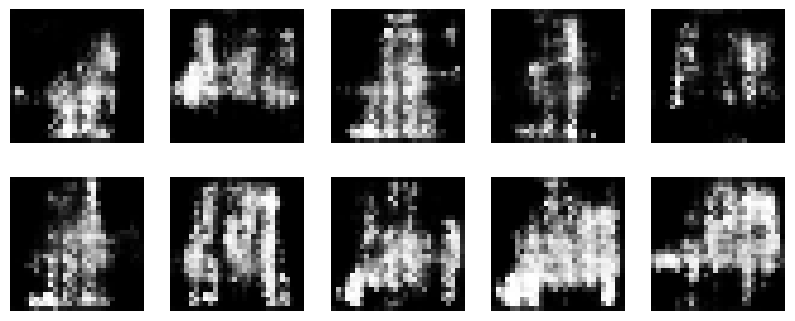

Epoch 4: Loss_D=0.908890426158905, Loss_G=1.5743331909179688


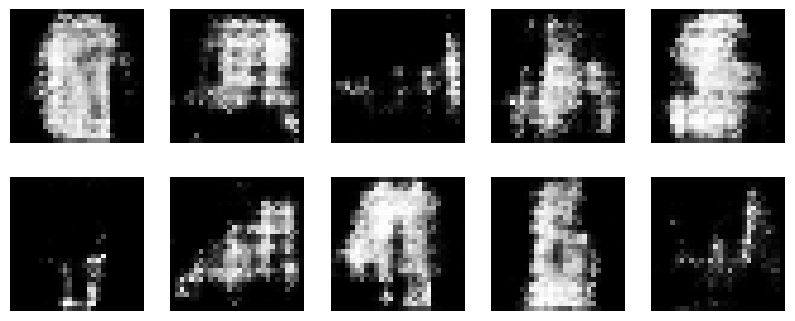

In [11]:
epochs = 4

for epoch in range(epochs):
    for real, _ in train_loader:
        real = real
        batch_size = real.size(0)
        real_labels = torch.ones(batch_size, 1)
        fake_labels = torch.zeros(batch_size, 1)

        noise = torch.randn(batch_size, 100)
        fake = generator(noise)

        loss_real = criterion(discriminator(real), real_labels)
        loss_fake = criterion(discriminator(fake.detach()), fake_labels)
        loss_D = loss_real + loss_fake

        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        output = discriminator(fake)
        loss_G = criterion(output, real_labels)
        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()
    print(f"Epoch {epoch+1}: Loss_D={loss_D.item()}, Loss_G={loss_G.item()}")


    noise = torch.randn(10, 100)
    fake_images = generator(noise).detach()
    fake_images = torch.permute(fake_images, (0, 2, 3, 1))
    fig, axs = plt.subplots(2, 5, figsize=(10,4))
    for i in range(10):
        axs[i//5, i%5].imshow(fake_images[i], cmap='gray')
        axs[i//5, i%5].axis('off')
    plt.show()

## **5. What challenges did you face during implementation or training? Can you explain why this might have happened?**

#### Challenges I faced:
    - The instability in training where the GAN is often oscillating which i think is because generator and discriminator are competing.
    - I trained the model with different learning rates and felt like it was sensitive to hyperparameters like learning rate.

## **6. Optional question: Does adding Batch normalization layers to your generator and discriminator make a difference in image generation quality or training stability?**

### **Repeat this process to train a GAN to generate MNIST digits with colored backgrounds (dataset is given in the colorized-MNIST folder), use torchvision.datasets.ImageFolder to load the dataset.**

#### Adding BatchNorm would stabilize training from what i know and it would improve image quality by normalizing intermediate activations. It is especially useful in generator to produce more diverse and stable outputs.

Im sorry i have no time to do this question :)....